# Step 1: 建立可視化資料 (Moons Dataset)

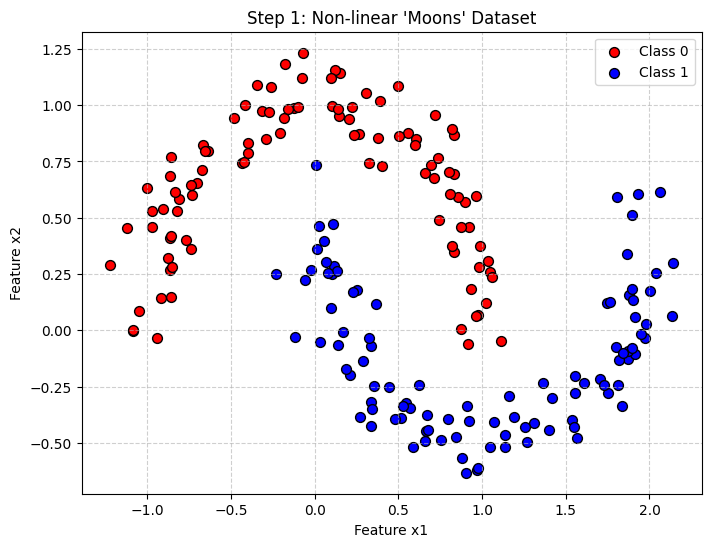

輸入資料形狀 X: (200, 2)
目標標籤形狀 y: (200, 1)


In [10]:
# ==========================================
# Step 1: 建立非線性資料 (Two Moons) 並可視化
# ==========================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

# 1. 產生雙半月形資料
# n_samples=200: 產生200個點
# noise=0.1: 加入一些雜訊，讓數據比較真實，不要太完美
# random_state=42: 固定亂數種子
X, y = make_moons(n_samples=200, noise=0.1, random_state=42)

# 調整 y 的形狀從 (200,) 變成 (200, 1) 以符合矩陣運算
y = y.reshape(-1, 1)

# 2. 可視化原始數據
plt.figure(figsize=(8, 6))
# 畫出類別 0 (紅色)
plt.scatter(X[y.flatten()==0][:, 0], X[y.flatten()==0][:, 1],
            color='red', edgecolor='k', s=50, label='Class 0')
# 畫出類別 1 (藍色)
plt.scatter(X[y.flatten()==1][:, 0], X[y.flatten()==1][:, 1],
            color='blue', edgecolor='k', s=50, label='Class 1')

plt.title("Step 1: Non-linear 'Moons' Dataset")
plt.xlabel("Feature x1")
plt.ylabel("Feature x2")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print(f"輸入資料形狀 X: {X.shape}")
print(f"目標標籤形狀 y: {y.shape}")

# Step 2: 定義 MLP 模型

In [11]:
# ==========================================
# Step 2: 定義 MLP 類別 (手動實作 Backpropagation)
# ==========================================

# 激活函數: Sigmoid
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Sigmoid 的導數 (用於反向傳播)
def sigmoid_derivative(x):
    return x * (1 - x)

class SimpleMLP:
    def __init__(self, input_size, hidden_size, output_size, learning_rate=0.1):
        self.learning_rate = learning_rate

        # 初始化權重 (Xavier/Glorot Initialization 比較好，但為了簡單演示使用均勻分佈)
        np.random.seed(42)
        self.W1 = np.random.uniform(-1, 1, (input_size, hidden_size))
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.uniform(-1, 1, (hidden_size, output_size))
        self.b2 = np.zeros((1, output_size))

        self.losses = [] # 記錄 Loss 變化

    def forward(self, X):
        # --- 前向傳播 ---
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = sigmoid(self.z1)      # 隱藏層輸出

        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.output = sigmoid(self.z2)  # 最終輸出
        return self.output

    def backward(self, X, y):
        # --- 反向傳播 ---
        m = X.shape[0]

        # 1. 計算輸出層誤差 (Gradient of Loss w.r.t Output)
        error_output = y - self.output  # (y - y_hat)
        d_output = error_output * sigmoid_derivative(self.output) # Delta 2

        # 2. 計算隱藏層誤差 (傳遞回來)
        error_hidden = d_output.dot(self.W2.T)
        d_hidden = error_hidden * sigmoid_derivative(self.a1)     # Delta 1

        # --- 3. 權重更新 (實現 w* = w + delta_w) ---
        # Delta w = learning_rate * (input.T dot delta)

        # 更新 W2 (Output Layer)
        delta_W2 = np.dot(self.a1.T, d_output)
        self.W2 += self.learning_rate * delta_W2  # <--- 數學實作: w* = w + delta_w
        self.b2 += self.learning_rate * np.sum(d_output, axis=0, keepdims=True)

        # 更新 W1 (Hidden Layer)
        delta_W1 = np.dot(X.T, d_hidden)
        self.W1 += self.learning_rate * delta_W1  # <--- 數學實作: w* = w + delta_w
        self.b1 += self.learning_rate * np.sum(d_hidden, axis=0, keepdims=True)

    def train(self, X, y, epochs):
        for epoch in range(epochs):
            output = self.forward(X)
            self.backward(X, y)

            # 計算 MSE Loss
            loss = np.mean(np.square(y - output))
            self.losses.append(loss)

            if epoch % 1000 == 0:
                print(f"Epoch {epoch}, Loss: {loss:.6f}")

# Step 3: 訓練與 Loss 曲線可視化

開始訓練 MLP (這可能需要幾秒鐘)...
Epoch 0, Loss: 0.330391
Epoch 1000, Loss: 0.003708
Epoch 2000, Loss: 0.001165
Epoch 3000, Loss: 0.000613
Epoch 4000, Loss: 0.000396
Epoch 5000, Loss: 0.000285
Epoch 6000, Loss: 0.000219
Epoch 7000, Loss: 0.000176
Epoch 8000, Loss: 0.000146
Epoch 9000, Loss: 0.000124
Epoch 10000, Loss: 0.000107
Epoch 11000, Loss: 0.000094
Epoch 12000, Loss: 0.000084
Epoch 13000, Loss: 0.000075
Epoch 14000, Loss: 0.000068
訓練完成！


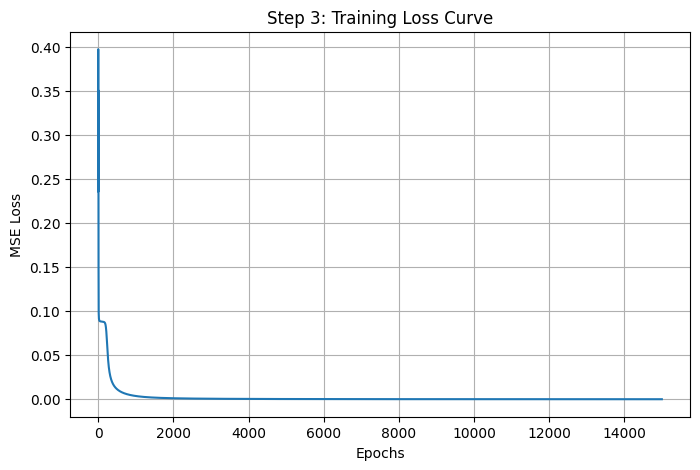

最終模型準確率: 100.00%


In [12]:
# ==========================================
# Step 3: 開始訓練模型並畫出 Loss 曲線
# ==========================================

# 建立模型: 2 輸入 -> 10 隱藏層神經元 (增加複雜度以擬合曲線) -> 1 輸出
mlp = SimpleMLP(input_size=2, hidden_size=10, output_size=1, learning_rate=0.1)

print("開始訓練 MLP (這可能需要幾秒鐘)...")
# 訓練 15000 次，確保收斂
mlp.train(X, y, epochs=15000)
print("訓練完成！")

# 繪製 Loss 曲線
plt.figure(figsize=(8, 5))
plt.plot(mlp.losses)
plt.title('Step 3: Training Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.grid(True)
plt.show()

# 計算準確率
preds = mlp.forward(X)
preds_class = (preds > 0.5).astype(int)
accuracy = np.mean(preds_class == y)
print(f"最終模型準確率: {accuracy * 100:.2f}%")

# Step 4: 最終分類邊界 (Contour Plot)

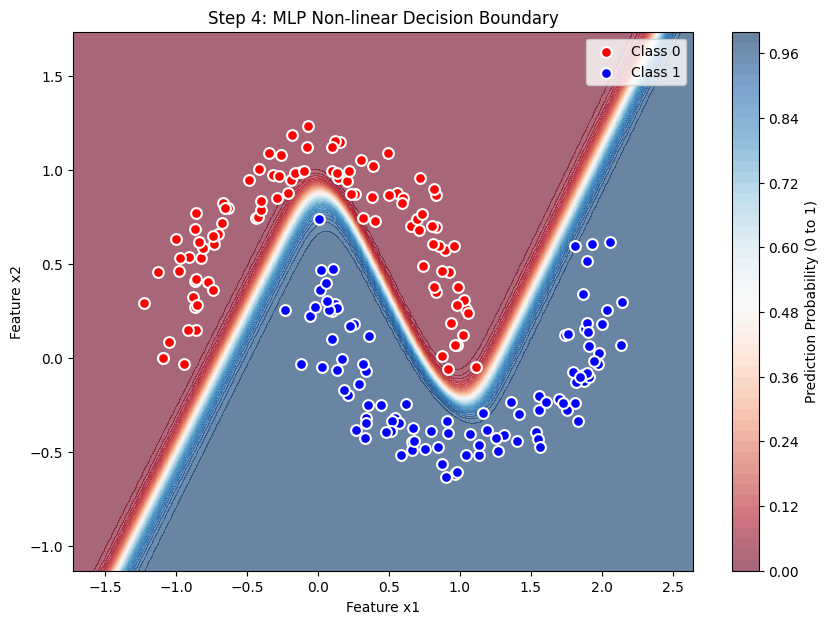

In [13]:
# ==========================================
# Step 4: 最終分類結果可視化 (Decision Boundary)
# ==========================================

def plot_decision_boundary(model, X, y):
    plt.figure(figsize=(10, 7))

    # 1. 建立網格 (Meshgrid)
    # 稍微擴大邊界，讓圖好看一點
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))

    # 2. 對網格上每一點進行預測
    # flatten() 拉平後丟進 model，出來再 reshape 回網格形狀
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    probs = model.forward(grid_points).reshape(xx.shape)

    # 3. 繪製等高線 (Decision Boundary)
    # 使用 RdBu colormap，中間白色代表機率 0.5 (決策邊界)
    contour = plt.contourf(xx, yy, probs, levels=50, cmap="RdBu", alpha=0.6)
    plt.colorbar(contour, label='Prediction Probability (0 to 1)')

    # 4. 繪製原始數據點
    plt.scatter(X[y.flatten()==0][:, 0], X[y.flatten()==0][:, 1],
                color='red', edgecolor='white', s=60, linewidth=1.5, label='Class 0')
    plt.scatter(X[y.flatten()==1][:, 0], X[y.flatten()==1][:, 1],
                color='blue', edgecolor='white', s=60, linewidth=1.5, label='Class 1')

    plt.title('Step 4: MLP Non-linear Decision Boundary')
    plt.xlabel('Feature x1')
    plt.ylabel('Feature x2')
    plt.legend()
    plt.show()

plot_decision_boundary(mlp, X, y)